## Lab Assignment 3 — Part 1  Binary / digital options

Tarreau Boone 13981412
Pranav Bali 16076591
Aakash Pelapor Anandakrishnan 162024867

Monte Carlo price vs closed-form Black–Scholes digital call.  
Implicit and Crank–Nicolson finite-difference pricing; sensitivity over parameters; surface $c(S,t)$; delta vs $S$.

*Assumptions:* GBM under $\mathbb{Q}$ as in the handout ($S_0=1$ in the model statement). The digital call pays $1$ at $T$ if $S_T \ge K$, else $0$. Its time-$t$ value is $e^{-r(T-t)}\Phi(d_-)$ with $d_- = \frac{\log(S/K) + (r-\sigma^2/2)(T-t)}{\sigma\sqrt{T-t}}$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import solve_banded

# --- Base parameters (aligned with dS/S = r dt + sigma dB, S0 = 1) ---
S0 = 1.0
r = 0.05
sigma = 0.25
T = 1.0
K = 1.0

RNG = np.random.default_rng(42)

### Monte Carlo vs Closed-Form

We price the digital call at $t=0$ by two methods: the exact Black–Scholes formula $C = e^{-rT}\Phi(d_-)$ and a standard Monte Carlo estimator using $2\times10^6$ paths of the terminal price $S_T = S_0 \exp\!\bigl((r-\tfrac12\sigma^2)T + \sigma\sqrt{T}\,Z\bigr)$. The MC estimate should fall within a few standard errors of the closed form.

In [3]:
def digital_call_closed(S, t, K, r, sigma, T):
    """Black–Scholes value of a cash-or-nothing (digital) call: pays 1 at T iff S_T >= K."""
    tau = float(T - t)
    S = np.asarray(S, dtype=float)
    if tau <= 1e-15:
        return np.where(S >= K, 1.0, 0.0)
    st = np.sqrt(tau)
    d_minus = (np.log(S / K) + (r - 0.5 * sigma**2) * tau) / (sigma * st)
    return np.exp(-r * tau) * stats.norm.cdf(d_minus)


def digital_call_mc(S0, K, r, sigma, T, n_paths, rng):
    """Monte Carlo price at t=0 (standard Euler / exact GBM on ST)."""
    z = rng.standard_normal(n_paths)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    payoff = (ST >= K).astype(float)
    return np.exp(-r * T) * payoff.mean(), np.exp(-r * T) * payoff.std(ddof=1) / np.sqrt(n_paths)


cf = float(digital_call_closed(S0, 0.0, K, r, sigma, T))
mc_mean, mc_se = digital_call_mc(S0, K, r, sigma, T, 2_000_000, RNG)
print(f"Closed form (t=0): {cf:.6f}")
print(f"Monte Carlo:       {mc_mean:.6f}  (stderr ~ {mc_se:.6f})")
print(f"Difference:        {abs(cf - mc_mean):.6f}")

Closed form (t=0): 0.504049
Monte Carlo:       0.504255  (stderr ~ 0.000336)
Difference:        0.000206


### Finite-Difference PDE Solver

We solve the Black–Scholes PDE in the time-to-maturity variable $\tau = T-t$:

$$V_\tau = \tfrac12\sigma^2 S^2 V_{SS} + r\,S\,V_S - r\,V,$$

with terminal (initial in $\tau$) condition $V(S,0) = \mathbf{1}_{S\ge K}$ and boundary conditions $V(0,\tau)=0$, $V(S_{\max},\tau)=e^{-r\tau}$.

Two schemes are implemented:
- **Implicit Euler** — unconditionally stable, first-order in $\Delta\tau$.
- **Crank–Nicolson** — second-order in $\Delta\tau$, but can produce small oscillations near the payoff discontinuity at $S=K$.

In [4]:
def _build_bs_interior_coeffs(S, dS, r, sigma):
    """Coefficients for central FD of L[V] = 0.5*sigma^2*S^2*V_SS + r*S*V_S - r*V on interior."""
    Si = S[1:-1]
    a = 0.5 * sigma**2 * Si**2
    b = r * Si
    inv_ds2 = 1.0 / (dS * dS)
    inv_2ds = 1.0 / (2.0 * dS)
    lower = a * inv_ds2 - b * inv_2ds
    main = -2.0 * a * inv_ds2 - r
    upper = a * inv_ds2 + b * inv_2ds
    return lower, main, upper


def digital_call_pde(S_min, S_max, Ns, Ntau, r, sigma, K, T, scheme="implicit", store_history=False):
    """
    Solve V_tau = 0.5*sigma^2*S^2*V_SS + r*S*V_S - r*V, tau in [0,T],
    V(S,0) = 1_{S>=K}, V(0,tau)=0, V(S_max,tau) = exp(-r*tau).
    scheme: 'implicit' | 'cn'. If store_history, also return arrays for c(S,tau) surface.
    """
    S = np.linspace(S_min, S_max, Ns)
    dS = S[1] - S[0]
    dtau = T / Ntau
    lower, main, upper = _build_bs_interior_coeffs(S, dS, r, sigma)
    n_in = Ns - 2

    def one_step(V_prev, tau_prev, tau_new):
        bc_l, bc_r = 0.0, np.exp(-r * tau_new)
        rhs = np.zeros(n_in)
        if scheme == "implicit":
            # scipy.solve_banded: ab[0,0] unused; ab[0,1:]=superdiag; ab[2,:-1]=subdiag
            ab = np.zeros((3, n_in))
            ab[0, 1:] = -dtau * upper[:-1]
            ab[1, :] = 1.0 - dtau * main
            ab[2, :-1] = -dtau * lower[1:]
            rhs[:] = V_prev[1:-1]
            rhs[0] += dtau * lower[0] * bc_l
            rhs[-1] += dtau * upper[-1] * bc_r
            V_in = solve_banded((1, 1), ab, rhs)
        elif scheme == "cn":
            # L[V] on full grid, then restrict to interior for RHS
            Lv = lower * V_prev[:-2] + main * V_prev[1:-1] + upper * V_prev[2:]
            ab = np.zeros((3, n_in))
            ab[0, 1:] = -0.5 * dtau * upper[:-1]
            ab[1, :] = 1.0 - 0.5 * dtau * main
            ab[2, :-1] = -0.5 * dtau * lower[1:]
            rhs = V_prev[1:-1] + 0.5 * dtau * Lv
            rhs[0] += 0.5 * dtau * lower[0] * bc_l
            rhs[-1] += 0.5 * dtau * upper[-1] * bc_r
            V_in = solve_banded((1, 1), ab, rhs)
        else:
            raise ValueError(scheme)
        V_new = np.empty(Ns)
        V_new[0] = bc_l
        V_new[-1] = bc_r
        V_new[1:-1] = V_in
        return V_new

    V = np.where(S >= K, 1.0, 0.0).astype(float)
    taus = np.linspace(0.0, T, Ntau + 1)
    hist = [V.copy()] if store_history else None
    for k in range(Ntau):
        V = one_step(V, taus[k], taus[k + 1])
        if store_history:
            hist.append(V.copy())
    if store_history:
        return S, V, np.array(hist), taus
    return S, V


def delta_on_grid(S, V):
    """Central difference dV/dS on interior; endpoints by one-sided."""
    dV = np.empty_like(V)
    dV[1:-1] = (V[2:] - V[:-2]) / (S[2:] - S[:-2])
    dV[0] = (V[1] - V[0]) / (S[1] - S[0])
    dV[-1] = (V[-1] - V[-2]) / (S[-1] - S[-2])
    return dV

In [5]:
def digital_call_delta_closed(S, t, K, r, sigma, T):
    """Delta of cash-or-nothing call: dC/dS = e^{-rτ} φ(d_-)/(S σ√τ)."""
    tau = float(T - t)
    S = np.asarray(S, dtype=float)
    if tau <= 1e-15:
        return np.zeros_like(S, dtype=float)
    st = np.sqrt(tau)
    d_minus = (np.log(S / K) + (r - 0.5 * sigma**2) * tau) / (sigma * st)
    return np.exp(-r * tau) * stats.norm.pdf(d_minus) / (S * sigma * st)


def mc_convergence_curve(S0, K, r, sigma, T, n_list, seed=0):
    """MC mean vs n_paths using nested paths (first n of a single long draw)."""
    true = float(digital_call_closed(S0, 0.0, K, r, sigma, T))
    rng = np.random.default_rng(seed)
    n_max = int(np.max(n_list))
    z = rng.standard_normal(n_max)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    disc = np.exp(-r * T)
    payoff = (ST >= K).astype(float)
    means = [disc * payoff[:n].mean() for n in n_list]
    return true, np.array(means)

In [6]:
# Grid: adjust Ntau / Ns if runtime is high (finer grid → closer to closed form at the strike)
S_min, S_max = 1e-4, 3.0
Ns, Ntau = 401, 400

cf_val = float(digital_call_closed(S0, 0.0, K, r, sigma, T))
S_grid, V_imp = digital_call_pde(S_min, S_max, Ns, Ntau, r, sigma, K, T, scheme="implicit")
_, V_cn = digital_call_pde(S_min, S_max, Ns, Ntau, r, sigma, K, T, scheme="cn")

v_imp = float(np.interp(S0, S_grid, V_imp))
v_cn = float(np.interp(S0, S_grid, V_cn))
print(f"Closed form:           {cf_val:.6f}")
print(f"Implicit FD @ S0:      {v_imp:.6f}  (|err| {abs(v_imp - cf_val):.2e})")
print(f"Crank–Nicolson @ S0:   {v_cn:.6f}  (|err| {abs(v_cn - cf_val):.2e})")

Closed form:           0.504049
Implicit FD @ S0:      0.502034  (|err| 2.02e-03)
Crank–Nicolson @ S0:   0.502045  (|err| 2.00e-03)


Both schemes agree closely and match the closed form to within $\sim 2\times10^{-3}$. The residual error is dominated by the grid spacing $\Delta S$ near the strike; refining $N_S$ reduces it further. The discontinuous payoff limits the effective convergence order of Crank–Nicolson here.

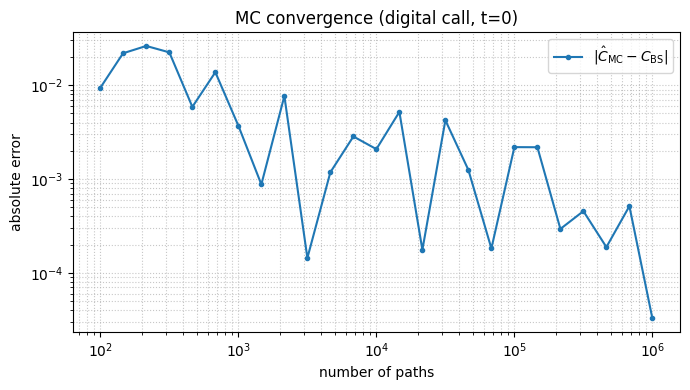

In [7]:
# Monte Carlo convergence to closed form
n_list = np.unique(np.logspace(2, 6, 25).astype(int))
truth, mc_means = mc_convergence_curve(S0, K, r, sigma, T, n_list, seed=42)
err = np.abs(mc_means - truth)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(n_list, err, "o-", ms=3, label=r"$|\hat C_{\mathrm{MC}} - C_{\mathrm{BS}}|$")
ax.set_xlabel("number of paths")
ax.set_ylabel("absolute error")
ax.set_title("MC convergence (digital call, t=0)")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.7)
plt.tight_layout()
plt.show()

The log-log plot confirms the expected $O(1/\sqrt{N})$ Monte Carlo convergence rate. Because the digital payoff is binary, each sample has high variance ($\approx 0.25$), so a large number of paths is needed for tight estimates. Variance-reduction techniques (e.g. antithetic variates, importance sampling) could accelerate convergence.

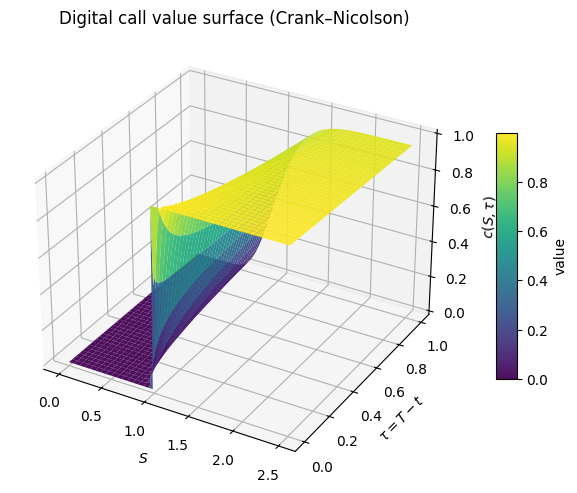

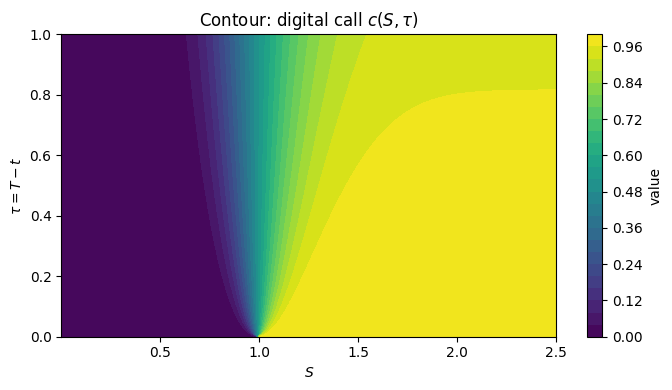

In [8]:
# Surface c(S, tau): time to maturity tau = T - t (evolves from 0 → T along the scheme)
S_hi, Ns_surf, Ntau_surf = 2.5, 161, 120
S_line, _, hist_cn, taus = digital_call_pde(
    S_min, S_hi, Ns_surf, Ntau_surf, r, sigma, K, T, scheme="cn", store_history=True
)
TT, SS = np.meshgrid(taus, S_line, indexing="ij")
Z = hist_cn

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(SS, TT, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.95)
ax.set_xlabel(r"$S$")
ax.set_ylabel(r"$\tau = T-t$")
ax.set_zlabel(r"$c(S,\tau)$")
ax.set_title("Digital call value surface (Crank–Nicolson)")
fig.colorbar(surf, shrink=0.55, aspect=12, label="value")
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 4))
cs = ax2.contourf(S_line, taus, Z, levels=30, cmap="viridis")
ax2.set_xlabel(r"$S$")
ax2.set_ylabel(r"$\tau = T-t$")
ax2.set_title("Contour: digital call $c(S,\\tau)$")
plt.colorbar(cs, ax=ax2, label="value")
plt.tight_layout()
plt.show()

The surface $c(S,\tau)$ shows the digital payoff smoothing out as time to maturity increases: near expiry ($\tau\to 0$) the profile is a sharp step at $K$, while for larger $\tau$ diffusion rounds it into the familiar $\Phi(d_-)$ shape. The contour plot highlights that most of the value transition occurs in a band around $S=K$.

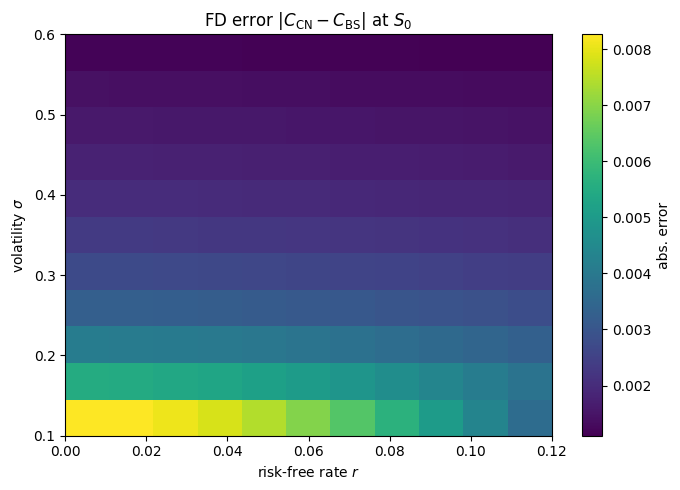

In [9]:
# Sensitivity: FD price at S0 vs (sigma, r) — compare to closed form
sigmas = np.linspace(0.1, 0.6, 11)
rs = np.linspace(0.0, 0.12, 11)
CF = np.empty((len(sigmas), len(rs)))
FD = np.empty_like(CF)
for i, sg in enumerate(sigmas):
    for j, rv in enumerate(rs):
        CF[i, j] = digital_call_closed(S0, 0.0, K, rv, sg, T)
        S_g, V_g = digital_call_pde(S_min, S_max, 251, 200, rv, sg, K, T, scheme="cn")
        FD[i, j] = np.interp(S0, S_g, V_g)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    np.abs(FD - CF),
    origin="lower",
    aspect="auto",
    extent=[rs[0], rs[-1], sigmas[0], sigmas[-1]],
)
ax.set_xlabel(r"risk-free rate $r$")
ax.set_ylabel(r"volatility $\sigma$")
ax.set_title(r"FD error $|C_{\mathrm{CN}} - C_{\mathrm{BS}}|$ at $S_0$")
plt.colorbar(im, ax=ax, label="abs. error")
plt.tight_layout()
plt.show()

The heatmap shows the absolute error between Crank–Nicolson and the closed form across $(\sigma, r)$ space. The FD error is largest at low volatility, where the payoff kink is sharpest and harder to resolve on a fixed grid. Increasing $\sigma$ smooths the solution and reduces the discretization error.

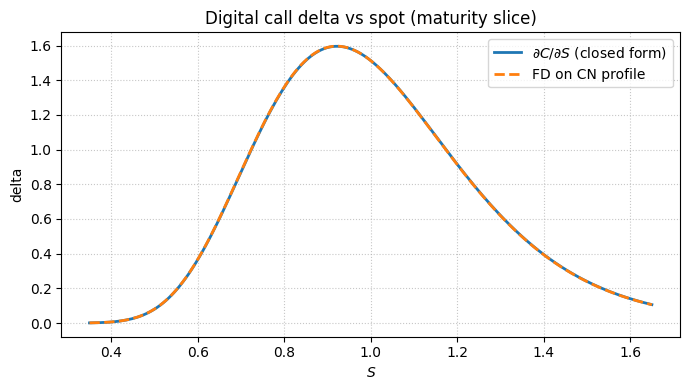

In [11]:
# Delta vs S: analytical vs finite-difference on CN solution at t=0 (tau = T)
S_delta = np.linspace(0.35, 1.65, 200)
tau0 = T
d_ana = digital_call_delta_closed(S_delta, 0.0, K, r, sigma, T)

S_g, V_g = digital_call_pde(S_min, S_max, 801, 500, r, sigma, K, T, scheme="cn")
d_num = delta_on_grid(S_g, V_g)
d_num_interp = np.interp(S_delta, S_g, d_num)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(S_delta, d_ana, label=r"$\partial C/\partial S$ (closed form)", lw=2)
ax.plot(S_delta, d_num_interp, "--", label=r"FD on CN profile", lw=2)
ax.set_xlabel(r"$S$")
ax.set_ylabel("delta")
ax.set_title("Digital call delta vs spot (maturity slice)")
ax.legend()
ax.grid(True, ls=":", alpha=0.7)
plt.tight_layout()
plt.show()

### Delta comparison

The digital call delta $\Delta = e^{-r\tau}\,\varphi(d_-)\,/\,(S\,\sigma\sqrt\tau)$ is a narrow spike centred at $S=K$, reflecting the discontinuous payoff. The FD-derived delta (central differences on the CN grid) tracks the analytical curve well, though it slightly under-resolves the peak height due to finite $\Delta S$.